In [9]:
import pandas as pd
import numpy as np
import random as rnd
import seaborn as sns
import matplotlib.pyplot as plt


In [11]:
%matplotlib inline

In [12]:
data=pd.read_csv(r"C:\Users\dell\Downloads\tested.csv")

In [13]:
data

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
413,1305,0,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,0,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,0,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


In [14]:
data.shape

(418, 12)

In [15]:
data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,418.000000,332.000000,418.000000,418.000000,417.000000
mean,1100.500000,0.363636,2.265550,30.272590,0.447368,0.392344,35.627188
std,120.810458,0.481622,0.841838,14.181209,0.896760,0.981429,55.907576
min,892.000000,0.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,0.000000,1.000000,21.000000,0.000000,0.000000,7.895800
50%,1100.500000,0.000000,3.000000,27.000000,0.000000,0.000000,14.454200
75%,1204.750000,1.000000,3.000000,39.000000,1.000000,0.000000,31.500000
max,1309.000000,1.000000,3.000000,76.000000,8.000000,9.000000,512.329200


In [16]:
data.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

In [17]:
data["Age"]=data["Age"].fillna(np.mean(data["Age"]))

In [18]:
data["Fare"]=data["Fare"].fillna(data["Fare"].mode()[0])

In [23]:
data=data.drop("Cabin", axis=1)

In [25]:
data.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [35]:
data[["Sex","Age"]].groupby(["Sex"],as_index=False).mean().sort_values(by="Age",ascending=True)

,Sex,Age
0,female,30.272400
1,male,30.272699


In [37]:
data[["SibSp","Survived"]].groupby(["SibSp"],as_index=False).mean().sort_values(by="SibSp",ascending=True)

,SibSp,Survived
0,0,0.310954
1,1,0.490909
2,2,0.428571
3,3,0.250000
4,4,0.250000
5,5,1.000000
6,8,0.500000


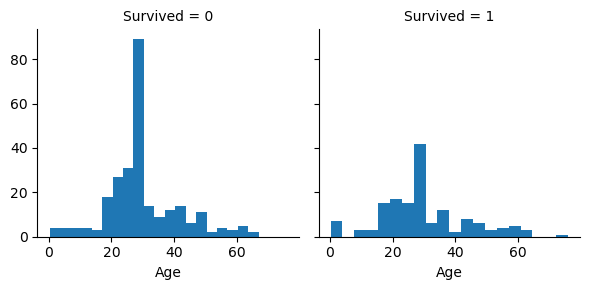

In [38]:
g=sns.FacetGrid(data,col="Survived")
g.map(plt.hist,"Age",bins=20)

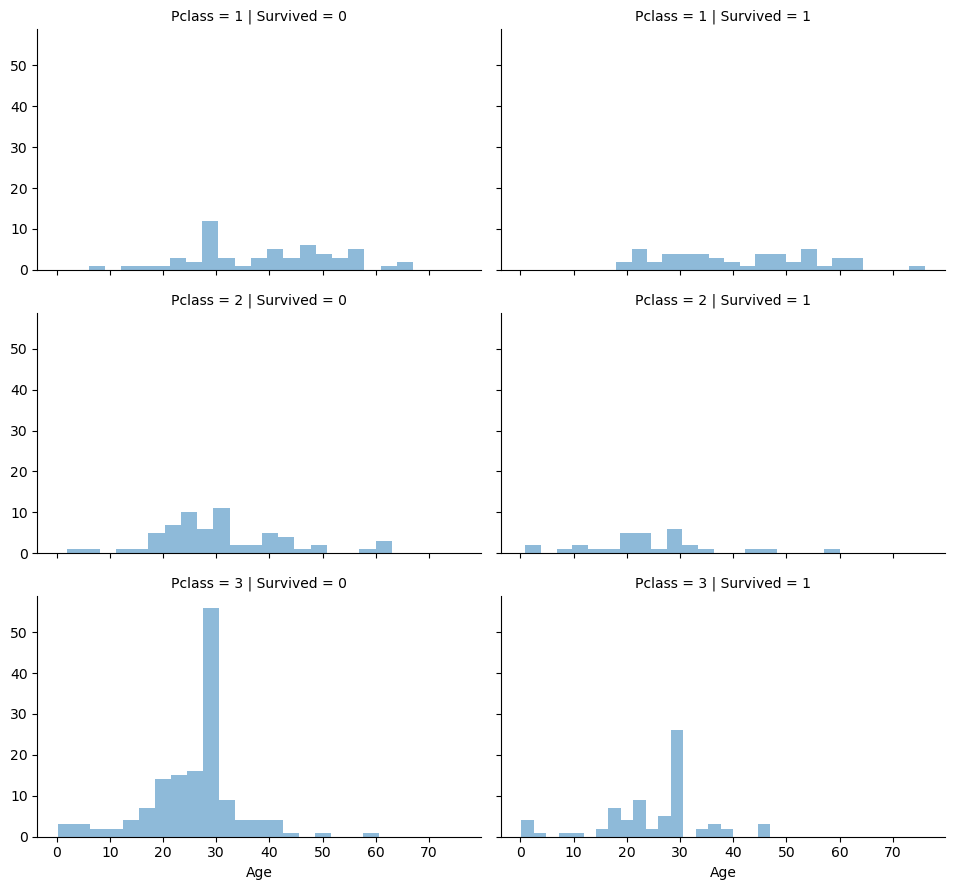

In [41]:
grid=sns.FacetGrid(data,col="Survived",row="Pclass",aspect=1.6)
grid.map(plt.hist,"Age",alpha=0.5,bins=20)
grid.add_legend()

C:\Users\dell\anaconda3\Lib\site-packages\seaborn\axisgrid.py:718: UserWarning: Using the barplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)
C:\Users\dell\anaconda3\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  func(*plot_args, **plot_kwargs)
C:\Users\dell\anaconda3\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  func(*plot_args, **plot_kwargs)
C:\Users\dell\anaconda3\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  func(*plot_args, **plot_kwargs)
C:\Users\dell\anaconda3\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  func(*plot_args, **plot_kwargs)
C:\Users\dell\anaconda3\L

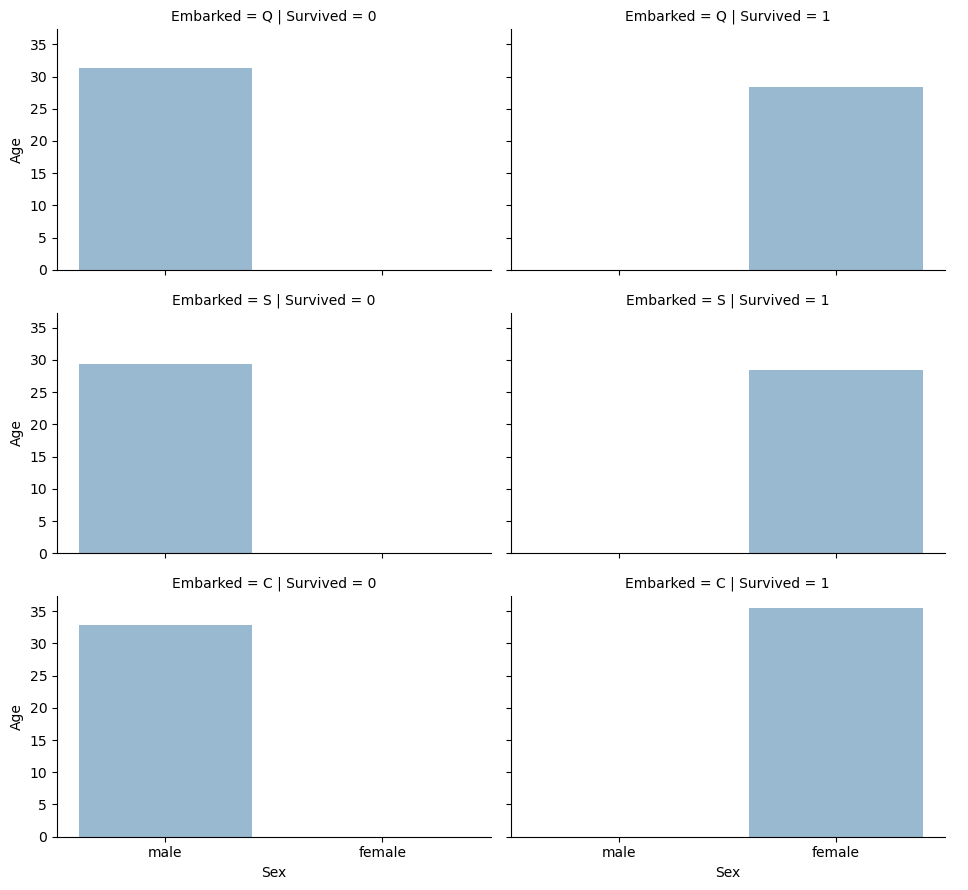

In [42]:
grid=sns.FacetGrid(data,row="Embarked",col="Survived",aspect=1.6)
grid.map(sns.barplot,"Sex","Age",alpha=0.5,ci=None)
grid.add_legend()

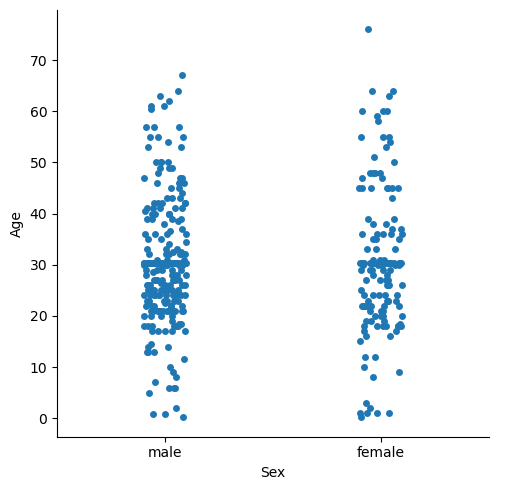

In [43]:
sns.catplot(x="Sex",y="Age",data=data,kind='strip')

<Axes: xlabel='Age', ylabel='Sex'>

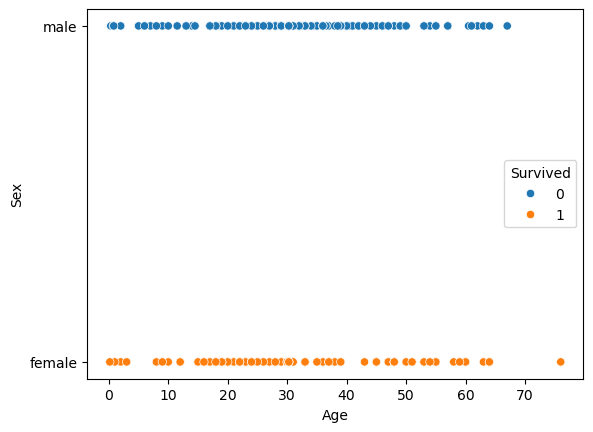

In [45]:
sns.scatterplot(x="Age",y="Sex",hue="Survived",data=data)

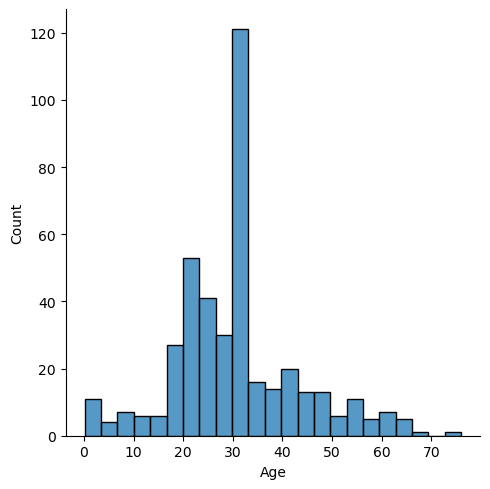

In [46]:
sns.displot(data["Age"])

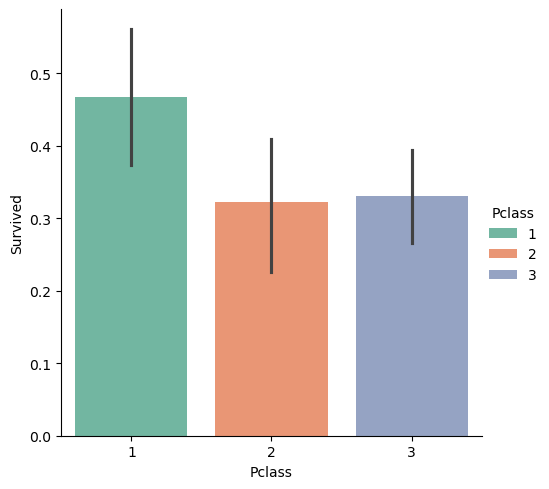

In [49]:
sns.catplot(x="Pclass",y="Survived",data=data,kind="bar",hue="Pclass",palette="Set2")

In [50]:
data[["Pclass","Survived"]].groupby(["Pclass"],as_index=False).mean()

,Pclass,Survived
0,1,0.467290
1,2,0.322581
2,3,0.330275


In [51]:
data[["Age","Survived"]].groupby(["Age"],as_index=False).mean()

,Age,Survived
0,0.17,1.000000
1,0.33,0.000000
2,0.75,0.000000
3,0.83,0.000000
4,0.92,1.000000
...,...,...
75,62.00,0.000000
76,63.00,0.500000
77,64.00,0.666667
78,67.00,0.000000


In [52]:
data[["Sex","Survived"]].groupby(["Sex"],as_index=False).mean()

,Sex,Survived
0,female,1.0
1,male,0.0


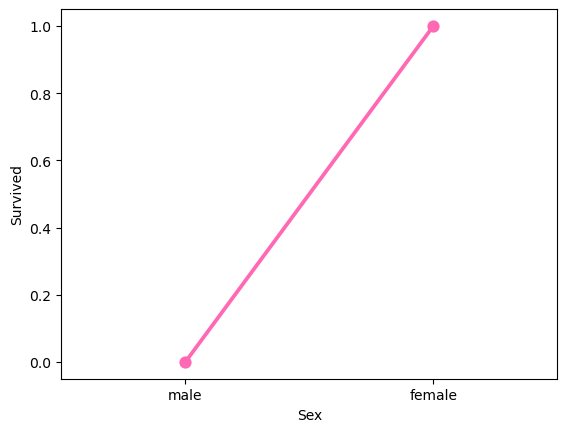

In [53]:
sns.pointplot(x="Sex",y="Survived",data=data,color="#FF69B4")
plt.show()

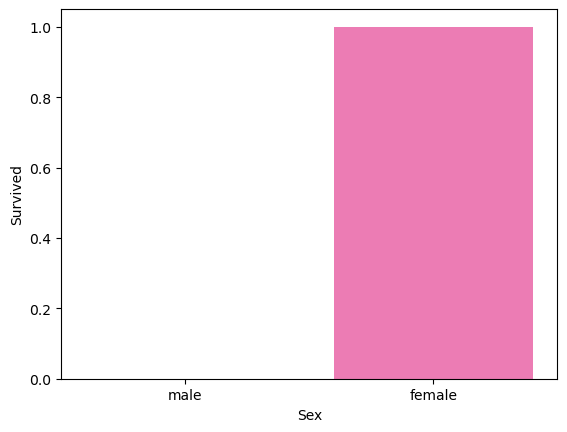

In [54]:
sns.barplot(x="Sex",y="Survived",data=data,color="#FF69B4")
plt.show()

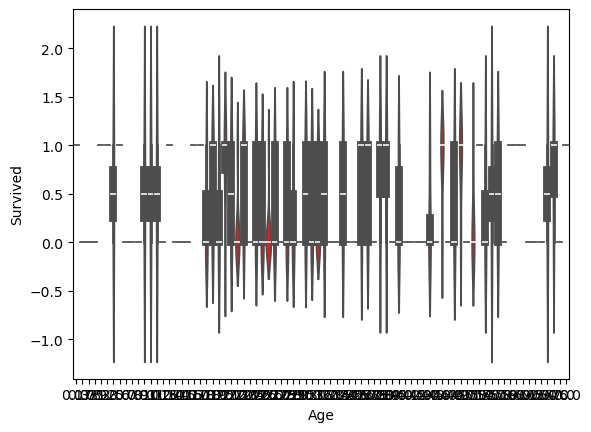

In [55]:
sns.violinplot(x="Age",y="Survived",data=data,color="Red")
plt.show()

C:\Users\dell\anaconda3\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 53.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\dell\anaconda3\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 46.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\dell\anaconda3\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 77.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\dell\anaconda3\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 64.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\dell\anaconda3\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 59.1% of the points cann

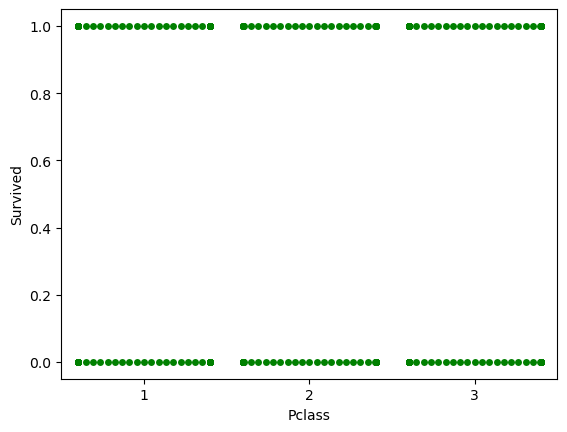

In [56]:
sns.swarmplot(x="Pclass",y="Survived",data=data,color="Green")
plt.show()